In [ ]:
import importlib
import sys

# ──────────── Paths (update for your machine) ────────────
ijepa_checkpoint = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/pretrained_enc_ckpts/ijepa/IN1K-vit.h.14-300e.pth.tar"
repo_root = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/StyleGAN2/seg-aware-stylegan2"
data_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/imagenet.zip"
out_base = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/StyleGAN2/seg-aware-stylegan2/outputs/debug_sam"

# SAM on-the-fly extraction (fallback for missing pre-computed)
sam_checkpoint = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/segProto/checkpoints/sam_vit_b_01ec64.pth"
# sam_cache_dir = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_cache_unified"  # same dir as pre-computed!
sam_cache_dir = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_temp"

# Pre-computed embeddings
# sam_npz_dir = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_cache_unified"
sam_npz_dir ="/scratch/gilbreth/abelde/Thesis/StructureAwareGen/region_emb_extract-a100-0.65dedup"
ijepa_npz_dir = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings"
origin_map_json = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/origin_map_imagenetdebug.json"

# RDM mixed training (set to a checkpoint path to enable, or None to skip)
rdm_checkpoint = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/rdm_out_final/IJEPA_local_feat/a100-rerun/2_nodes/checkpoint-last.pth"

# ──────────── Hyperparams ────────────
SAM_PROB = 0.5            # Network sees SAM tokens 50% of the time
SEM_MIX = 0.9
FUSION_ALPHA = 0.2
LAMBDA_SEG_ALIGN = 0.1
LAMBDA_SEG_DIVERSITY = 0.05

outdir = f"{out_base}/debug-run"

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import train
importlib.reload(train)

# ──────────── Build CLI args ────────────
sys.argv = [
    "train.py",
    "--outdir", outdir,
    "--data", data_path,
    "--subset", "20",       # LIMIT TO 20 IMAGES FOR DEBUGGING
    "--gpus", "1",
    "--cond", "1",
    "--batch", "4",
    "--kimg", "1",

    # I-JEPA options
    "--ijepa_checkpoint", ijepa_checkpoint,
    "--ijepa_lambda", "1.0",
    "--ijepa_image", "256",
    "--ijepa_input_channel", "3",
    "--ijepa_dim", "1280",
    "--ijepa_warmup_kimg", "0.5",
    "--sem_mixing_prob", str(SEM_MIX),
    "--fusion_alpha", str(FUSION_ALPHA),
    "--origin-map-json", origin_map_json,

    # Pre-computed embeddings (AlignedSegDataset loads from npz)
    "--use-seg-embeddings",
    "--sam-npz-dir", sam_npz_dir,
    "--ijepa-npz-dir", ijepa_npz_dir,

    # SAM on-the-fly fallback (extracts missing, saves to sam_cache_dir)
    "--sam-enabled", "true",
    "--sam-prob", str(SAM_PROB),
    "--sam-checkpoint", sam_checkpoint,
    "--sam-cache-dir", sam_cache_dir,
    "--sam-model-type", "vit_b",
    "--sam-max-masks", "250",
    "--sam-emb-logging", "true",

    # Alignment & diversity loss weights
    "--lambda-seg-align", str(LAMBDA_SEG_ALIGN),
    "--lambda-seg-diversity", str(LAMBDA_SEG_DIVERSITY),

    "--resume", "noresume",
]

# ── Optional: RDM mixed training ──
if rdm_checkpoint is not None:
    sys.argv += [
        "--rdm-checkpoint", rdm_checkpoint,
        "--rdm-mix-prob", "0.3",
        "--rdm-warmup-kimg", "0",
    ]

# Run

train.main(standalone_mode=False)

Using AlignedSegDataset with pre-computed embeddings
  SAM embeddings: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_temp
  I-JEPA embeddings: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings
  Origin map: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/origin_map_imagenetdebug.json
  Max segments: 250
  Loaded origin_map with 5000 entries from /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/origin_map_imagenetdebug.json
  origin_map sanity check: '00000/img00000000.png' -> '0/105557' OK
AlignedSegDataset initialized:
  Images: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/imagenet.zip
  SAM embeddings: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_temp
  I-JEPA embeddings: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings
  Origin map entries: 5000
  Max segments: 250
  Use labels (conditional): True
[3, 256, 256]

Training options:
{
  "num_gpus": 1,
  "image_snapshot_ticks": 50,
  "network

: 

In [1]:
# ──────────── UPDATED ARGV (H5 dataset + region_vit on-the-fly, self-contained) ────────────
import importlib
import sys

# Paths (redeclared here so this cell can run independently)
ijepa_checkpoint = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/pretrained_enc_ckpts/ijepa/IN1K-vit.h.14-300e.pth.tar"
repo_root = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/StyleGAN2/seg-aware-stylegan2"
data_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/imagenet.zip"
out_base = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/StyleGAN2/seg-aware-stylegan2/outputs/debug_sam"

# SAM on-the-fly extraction (fallback for missing pre-computed)
sam_checkpoint = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/segProto/checkpoints/sam_vit_b_01ec64.pth"
sam_cache_dir = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_temp"

# Region cache root (used for projection file in region_vit mode)
region_cache_dir = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/region_emb_extract-a100-0.65dedup"

# H5 embeddings (dataset side)
sam_h5_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_emb_flat.h5"
ijepa_h5_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_emb_flat.h5"
ijepa_lookup_json = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_lookup.json"
origin_map_json = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/origin_map_imagenetdebug.json"

# RDM mixed training (set None to disable)
rdm_checkpoint = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/rdm_out_final/IJEPA_local_feat/a100-rerun/2_nodes/checkpoint-last.pth"

# Hyperparams
SAM_PROB = 0.5
SEM_MIX = 0.9
FUSION_ALPHA = 0.2
LAMBDA_SEG_ALIGN = 0.1
LAMBDA_SEG_DIVERSITY = 0.05

outdir = f"{out_base}/debug-run"
region_proj_path = f"{region_cache_dir}/projection_ijepa_vit_h14.pt"
sam_h5_delta_dir = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_deltas_debug"

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import train
importlib.reload(train)

# Build updated CLI args with new SAM extractor options
sys.argv = [
    "train.py",
    "--outdir", outdir,
    "--data", data_path,
    "--subset", "20",
    "--gpus", "1",
    "--cond", "1",
    "--batch", "4",
    "--kimg", "1",

    # I-JEPA options
    "--ijepa_checkpoint", ijepa_checkpoint,
    "--ijepa_lambda", "1.0",
    "--ijepa_image", "256",
    "--ijepa_input_channel", "3",
    "--ijepa_dim", "1280",
    "--ijepa_warmup_kimg", "0.5",
    "--sem_mixing_prob", str(SEM_MIX),
    "--fusion_alpha", str(FUSION_ALPHA),
    "--origin-map-json", origin_map_json,

    # Pre-computed embeddings (H5 only)
    "--use-seg-embeddings",
    "--sam-h5-path", sam_h5_path,
    "--ijepa-h5-path", ijepa_h5_path,
    "--ijepa-lookup-json", ijepa_lookup_json,

    # SAM on-the-fly fallback
    "--sam-enabled", "true",
    "--sam-prob", str(SAM_PROB),
    "--sam-checkpoint", sam_checkpoint,
    "--sam-cache-dir", sam_cache_dir,
    "--sam-model-type", "vit_b",
    "--sam-max-masks", "100",
    "--sam-emb-logging", "true",

    # New extractor mode/options
    "--sam-emb-source", "region_vit",
    "--sam-region-backbone", "ijepa_vit_h14",
    "--sam-region-ijepa-checkpoint", ijepa_checkpoint,
    "--sam-region-proj-path", region_proj_path,
    "--sam-region-max-keep", "100",
    "--sam-region-dedup-iou-thresh", "0.65",
    "--sam-region-min-quality-score", "0.75",
    "--sam-region-min-area-frac", "0.001",
    "--sam-region-max-area-frac", "0.85",
    "--no-sam-region-mean-subtract",
    "--sam-crop-overlap-ratio", "0.35",
    "--sam-crop-n-points-downscale", "2",
    "--sam-h5-delta-dir", sam_h5_delta_dir,
    "--no-sam-preextract",

    # Alignment & diversity loss weights
    "--lambda-seg-align", str(LAMBDA_SEG_ALIGN),
    "--lambda-seg-diversity", str(LAMBDA_SEG_DIVERSITY),

    "--resume", "noresume",
]

if rdm_checkpoint is not None:
    sys.argv += [
        "--rdm-checkpoint", rdm_checkpoint,
        "--rdm-mix-prob", "0.3",
        "--rdm-warmup-kimg", "0",
    ]

train.main(standalone_mode=False)


Using AlignedSegDataset with pre-computed embeddings
  SAM H5 embeddings: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_emb_flat.h5
  I-JEPA H5 embeddings: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_emb_flat.h5
  I-JEPA lookup JSON: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_lookup.json
  Origin map: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/origin_map_imagenetdebug.json
  Max segments: 250
  Loaded origin_map with 5000 entries from /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/origin_map_imagenetdebug.json
  origin_map sanity check: '00000/img00000000.png' -> '0/105557' OK
AlignedSegDataset initialized:
  Images: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/imagenet.zip
  SAM source: H5
    SAM H5 path: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_emb_flat.h5
    SAM H5 index entries: 510172
  I-JEPA source: H5
    I-JEPA H5 path

2026-02-28 21:47:01.251388: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772333221.828297 3427081 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772333222.039279 3427081 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772333223.511689 3427081 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772333223.511716 3427081 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772333223.511719 3427081 computation_placer.cc:177] computation placer alr

Training for 1 kimg...

[SAMExtractor][Rank 0] Loading SAM model from /scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/segProto/checkpoints/sam_vit_b_01ec64.pth
[SAMExtractor][Rank 0] SAM model loaded successfully (points_per_side=32, pred_iou_thresh=0.82)
[SAMExtractor][Rank 0] Loading region backbone=ijepa_vit_h14
[SAMExtractor][Rank 0] Region backbone loaded (embed_dim=1280, patch=14, input=224)
tick 0     kimg 0.0      time 4m 06s       sec/tick 34.9    sec/kimg 8728.88 maintenance 211.0  cpumem 8.10   gpumem 8.64   augment 0.000
Evaluating metrics...
{"results": {"fid50k_full": 275.1645264875398}, "metric": "fid50k_full", "total_time": 453.8112277984619, "total_time_str": "7m 34s", "num_gpus": 1, "snapshot_pkl": "network-snapshot-000000.pkl", "timestamp": 1772333774.156213}
tick 1     kimg 1.0      time 14m 46s      sec/tick 162.8   sec/kimg 163.49  maintenance 477.3  cpumem 8.75   gpumem 9.08   augment 0.002
Evaluating metrics...
{"results": {"fid50k_full": 374.284155180

In [2]:
# Sample embeddings from your trained RDM checkpoint and inspect shapes/stats.

import sys
from pathlib import Path
import torch
import numpy as np
import torch.nn.functional as F

# --- paths ---
repo_root = Path("/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/StyleGAN2/seg-aware-stylegan2")
rdm_ckpt = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/rdm_out_final/IJEPA_local_feat/a100-rerun/2_nodes/checkpoint-last.pth"

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from training.rdm_sampler import RDMSampler

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Optional reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- load sampler ---
sampler = RDMSampler(
    rdm_checkpoint_path=rdm_ckpt,
    device=device,
    use_ema=True,
    ddim_steps=50,
)

# --- sample ---
batch_size = 4
num_segments = 180
samples = sampler.sample(batch_size=batch_size, num_segments=num_segments, use_ddim=True)

global_vec = samples["global_vec"]      # [B, 256]
seg_tokens = samples["seg_tokens"]      # [B, N, 256]
num_seg = samples["num_segments"]       # [B]

print("\n=== Shapes ===")
print("global_vec   :", tuple(global_vec.shape), global_vec.dtype, global_vec.device)
print("seg_tokens   :", tuple(seg_tokens.shape), seg_tokens.dtype, seg_tokens.device)
print("num_segments :", tuple(num_seg.shape), num_seg.dtype, num_seg.device, "| values:", num_seg.tolist())

def summarize_tensor(name, x):
    x_cpu = x.detach().float().cpu()
    print(f"\n{name}")
    print("  shape:", tuple(x_cpu.shape))
    print("  min/max:", float(x_cpu.min()), float(x_cpu.max()))
    print("  mean/std:", float(x_cpu.mean()), float(x_cpu.std()))
    if x_cpu.ndim >= 2:
        flat = x_cpu.reshape(x_cpu.shape[0], -1)
        norms = torch.norm(flat, dim=1)
        print("  L2 norms (first 4):", [float(v) for v in norms[:4]])

summarize_tensor("global_vec", global_vec)
summarize_tensor("seg_tokens", seg_tokens)

# Quick similarity checks
gv = F.normalize(global_vec.float(), dim=1)
sim = gv @ gv.T
print("\nGlobal vec cosine similarity matrix [B x B]:")
print(sim.detach().cpu().numpy())

# Inspect first sample, first 3 segment tokens (first 8 dims only for readability)
st0 = seg_tokens[0].detach().cpu().numpy()
print("\nFirst sample:")
print("  seg token count:", st0.shape[0])
print("  token dim:", st0.shape[1])
print("  first 3 tokens, first 8 dims:\n", st0[:3, :8])

# Optional: save to NPZ
# np.savez("rdm_sample_debug.npz",
#          global_vec=global_vec.detach().cpu().numpy(),
#          seg_tokens=seg_tokens.detach().cpu().numpy(),
#          num_segments=num_seg.detach().cpu().numpy())


device: cuda
Loading RDM checkpoint from: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/rdm_out_final/IJEPA_local_feat/a100-rerun/2_nodes/checkpoint-last.pth
[RDM] Skipping pretrained encoder init (not needed for sampling)
UnifiedSegRDM: Running in x0-prediction mode
DiffusionWrapper has 63.72 M params.
Keeping EMAs of 110.
Training UnifiedSegRDM as an unconditional model.
UnifiedSegRDM: max_segments=250, seg_npz_dir=None
  Diversity loss weight: 0.05
  Alignment loss weight: 0.05
  Normalize SAM tokens: False
  Embedding source: sam
  Alignment projection: 256 -> 256 (trainable=False)
[RDM] Loading EMA weights
[RDM] Model loaded successfully (epoch=199, EMA=True)

=== Shapes ===
global_vec   : (4, 256) torch.float32 cuda:0
seg_tokens   : (4, 180, 256) torch.float32 cuda:0
num_segments : (4,) torch.int64 cpu | values: [180, 180, 180, 180]

global_vec
  shape: (4, 256)
  min/max: -3.52360200881958 2.9691545963287354
  mean/std: -0.0031344741582870483 0.9959667921

In [6]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

# ---- paths ----
repo_root = Path("/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/StyleGAN2/seg-aware-stylegan2")
rdm_ckpt = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/rdm_out_final/IJEPA_local_feat/a100-rerun/2_nodes/checkpoint-last.pth"

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from training.rdm_sampler import RDMSampler

# ---- config ----
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

n_samples = 5000
batch_size = 32
num_segments = 100
ddim_steps = 50

# ---- sampler ----
sampler = RDMSampler(
    rdm_checkpoint_path=rdm_ckpt,
    device=device,
    use_ema=True,
    ddim_steps=ddim_steps,
)

# ---- sample with progress bar ----
all_global, all_seg = [], []
remaining = n_samples

with torch.no_grad():
    with tqdm(total=n_samples, desc="Sampling RDM embeddings", unit="sample") as pbar:
        while remaining > 0:
            b = min(batch_size, remaining)
            out = sampler.sample(batch_size=b, num_segments=num_segments, use_ddim=True)
            all_global.append(out["global_vec"].detach().cpu())   # [b, 256]
            all_seg.append(out["seg_tokens"].detach().cpu())      # [b, N, 256]
            remaining -= b
            pbar.update(b)

global_vec = torch.cat(all_global, dim=0)[:n_samples]        # [1000, 256]
seg_tokens = torch.cat(all_seg, dim=0)[:n_samples]           # [1000, 180, 256]
seg_pooled = seg_tokens.mean(dim=1)                          # [1000, 256]

def offdiag_cos_stats(x: torch.Tensor):
    x = F.normalize(x.float(), dim=1)
    sim = x @ x.T
    n = sim.shape[0]
    offdiag = sim[~torch.eye(n, dtype=torch.bool, device=sim.device)].cpu().numpy()
    return {
        "mean": float(offdiag.mean()),
        "std": float(offdiag.std()),
        "p05": float(np.percentile(offdiag, 5)),
        "p50": float(np.percentile(offdiag, 50)),
        "p95": float(np.percentile(offdiag, 95)),
        "frac_gt_0.7": float((offdiag > 0.7).mean()),
        "frac_gt_0.8": float((offdiag > 0.8).mean()),
        "frac_gt_0.9": float((offdiag > 0.9).mean()),
    }

def effective_rank(x: torch.Tensor, eps: float = 1e-12):
    x = x.float() - x.float().mean(dim=0, keepdim=True)
    cov = (x.T @ x) / max(1, x.shape[0] - 1)
    evals = torch.linalg.eigvalsh(cov).clamp_min(eps)
    p = evals / evals.sum()
    erank = torch.exp(-(p * torch.log(p)).sum())
    return float(erank.item())

def intra_sample_seg_cos(seg_tokens: torch.Tensor, max_items: int = 256):
    idx = torch.randperm(seg_tokens.shape[0])[:min(max_items, seg_tokens.shape[0])]
    means = []
    for i in tqdm(idx.tolist(), desc="Intra-sample seg cosine", unit="img"):
        t = F.normalize(seg_tokens[i].float(), dim=1)  # [N, 256]
        s = t @ t.T
        n = s.shape[0]
        off = s[~torch.eye(n, dtype=torch.bool, device=s.device)]
        means.append(float(off.mean().item()))
    arr = np.array(means, dtype=np.float32)
    return {
        "num_samples_used": int(len(arr)),
        "mean": float(arr.mean()),
        "std": float(arr.std()),
        "p05": float(np.percentile(arr, 5)),
        "p50": float(np.percentile(arr, 50)),
        "p95": float(np.percentile(arr, 95)),
    }

diversity_report = {
    "n_samples": n_samples,
    "num_segments": num_segments,
    "global_vec_shape": tuple(global_vec.shape),
    "seg_tokens_shape": tuple(seg_tokens.shape),
    "global_inter_sample_cos": offdiag_cos_stats(global_vec),
    "seg_pooled_inter_sample_cos": offdiag_cos_stats(seg_pooled),
    "seg_intra_sample_cos": intra_sample_seg_cos(seg_tokens, max_items=256),
    "effective_rank": {
        "global_vec": effective_rank(global_vec),
        "seg_pooled": effective_rank(seg_pooled),
    },
}

diversity_report


{'n_samples': 5000,
 'num_segments': 100,
 'global_vec_shape': (5000, 256),
 'seg_tokens_shape': (5000, 100, 256),
 'global_inter_sample_cos': {'mean': 0.5084867477416992,
  'std': 0.29370662569999695,
  'p05': -0.025244388822466136,
  'p50': 0.5440115332603455,
  'p95': 0.9214134246110917,
  'frac_gt_0.7': 0.3146398079615923,
  'frac_gt_0.8': 0.19308581716343268,
  'frac_gt_0.9': 0.07352286457291458},
 'seg_pooled_inter_sample_cos': {'mean': 0.12325406819581985,
  'std': 0.12924057245254517,
  'p05': -0.06882801093161106,
  'p50': 0.11876855790615082,
  'p95': 0.3410599544644356,
  'frac_gt_0.7': 0.0001443488697739548,
  'frac_gt_0.8': 1.7123424684936986e-05,
  'frac_gt_0.9': 0.0},
 'seg_intra_sample_cos': {'num_samples_used': 256,
  'mean': 0.19899266958236694,
  'std': 0.061193641275167465,
  'p05': 0.11317900195717812,
  'p50': 0.19711503386497498,
  'p95': 0.31080273538827896},
 'effective_rank': {'global_vec': 9.512796401977539,
  'seg_pooled': 133.67181396484375}}

In [7]:
import h5py
import numpy as np
from tqdm.auto import tqdm

h5_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_emb_flat.h5"

# ---- settings ----
seed = 42
n_sample = 100_000      # embeddings to sample from 1.2M
n_pairs = 300_000       # random cosine pairs for stats
chunk = 4096            # H5 load chunk
n_erank = 50_000        # subset for effective-rank estimate

rng = np.random.default_rng(seed)

with h5py.File(h5_path, "r") as f:
    assert "emb" in f, f"'emb' not found. Keys: {list(f.keys())}"
    emb = f["emb"]  # expected shape [N, 1280]
    N, D = emb.shape
    n_sample_eff = min(n_sample, N)

    # sample indices from full dataset
    idx = np.sort(rng.choice(N, size=n_sample_eff, replace=False))

    # load sampled embeddings with progress
    parts = []
    for s in tqdm(range(0, n_sample_eff, chunk), desc="Loading sampled embeddings"):
        ii = idx[s:s+chunk]
        parts.append(emb[ii].astype(np.float32))
    X = np.concatenate(parts, axis=0)  # [n_sample_eff, D]

# L2 normalize for cosine stats
Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

# random pair cosine stats (no full NxN matrix)
i = rng.integers(0, Xn.shape[0], size=n_pairs)
j = rng.integers(0, Xn.shape[0], size=n_pairs)
same = (i == j)
if same.any():
    j[same] = (j[same] + 1) % Xn.shape[0]

cos = np.sum(Xn[i] * Xn[j], axis=1)

# effective rank on subset
m = min(n_erank, X.shape[0])
ix_er = rng.choice(X.shape[0], size=m, replace=False)
Xe = X[ix_er]
Xe = Xe - Xe.mean(axis=0, keepdims=True)
cov = (Xe.T @ Xe) / max(1, (m - 1))  # [D, D]
evals = np.linalg.eigvalsh(cov).clip(min=1e-12)
p = evals / evals.sum()
erank = float(np.exp(-(p * np.log(p)).sum()))

report_real = {
    "h5_path": h5_path,
    "N_total": int(N),
    "dim": int(D),
    "n_sampled": int(X.shape[0]),
    "n_pairs": int(n_pairs),
    "cos_stats": {
        "mean": float(cos.mean()),
        "std": float(cos.std()),
        "p05": float(np.percentile(cos, 5)),
        "p50": float(np.percentile(cos, 50)),
        "p95": float(np.percentile(cos, 95)),
        "frac_gt_0.7": float((cos > 0.7).mean()),
        "frac_gt_0.8": float((cos > 0.8).mean()),
        "frac_gt_0.9": float((cos > 0.9).mean()),
    },
    "effective_rank": {
        "value": erank,
        "ratio_to_dim": float(erank / D),
        "n_used": int(m),
    },
}

report_real

{'h5_path': '/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_emb_flat.h5',
 'N_total': 1281167,
 'dim': 1280,
 'n_sampled': 100000,
 'n_pairs': 300000,
 'cos_stats': {'mean': 0.4215015470981598,
  'std': 0.2991957366466522,
  'p05': -0.060576916858553875,
  'p50': 0.4325379282236099,
  'p95': 0.8801502883434295,
  'frac_gt_0.7': 0.21756,
  'frac_gt_0.8': 0.11918333333333334,
  'frac_gt_0.9': 0.03567},
 'effective_rank': {'value': 11.918950080871582,
  'ratio_to_dim': 0.009311679750680923,
  'n_used': 50000}}

In [ ]:
# In notebook — check real data global vec diversity
import h5py, numpy as np, torch, torch.nn.functional as F

with h5py.File("/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_emb_flat.h5", "r") as f:
    idx = np.random.default_rng(42).choice(f["emb"].shape[0], 5000, replace=False)
    X = f["emb"][np.sort(idx)]  # [5000, 1280]

X = torch.tensor(X)
Xn = F.normalize(X.float(), dim=1)
sim = Xn @ Xn.T
n = sim.shape[0]
off = sim[~torch.eye(n, dtype=torch.bool)].numpy()
print("real ijepa inter-sample cos mean:", off.mean())
print("real ijepa inter-sample cos std: ", off.std())
print("frac > 0.7:", (off > 0.7).mean())

In [ ]:
import zipfile
z=zipfile.ZipFile('/scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/imagenet_debug_subset.zip')
print(z.namelist()[:20])

In [ ]:
cd /scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/StyleGAN2/seg-aware-stylegan2
python generate_origin_map.py \
    --source /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/imagenet_debug_subset/train \
    --dest /scratch/gilbreth/abelde/Thesis/StructureAwareGen/dataset/256/origin_map_imagenetdebug.json

In [1]:
import os
import numpy as np

npz_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/1/2470.npz"

print("File:", npz_path)
print("On-disk size (MB):", os.path.getsize(npz_path) / (1024**2))

data = np.load(npz_path, allow_pickle=True)

print("\nKeys:", data.files)

for k in data.files:
    v = data[k]
    if isinstance(v, np.ndarray):
        print(f"\n{k}:")
        print("  shape:", v.shape)
        print("  dtype:", v.dtype)
        print("  nbytes in RAM (MB):", v.nbytes / (1024**2))
        # quick stats (skip for object arrays)
        if v.dtype != object and v.size > 0:
            try:
                print("  min/max:", float(np.min(v)), float(np.max(v)))
                print("  mean/std:", float(np.mean(v)), float(np.std(v)))
            except Exception:
                pass
    else:
        print(f"\n{k}: (non-ndarray) type={type(v)}")

data.close()


File: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/1/2470.npz
On-disk size (MB): 0.0047588348388671875

Keys: ['emb']

emb:
  shape: (1280,)
  dtype: float32
  nbytes in RAM (MB): 0.0048828125
  min/max: -3.570686101913452 2.9386324882507324
  mean/std: -7.450580596923828e-09 0.9999998807907104


In [2]:
import os
import torch

pth_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/rdm_out_final/4_nodes/batch_64/ijepa_and_seg_aware/checkpoint-last.pth"

print("File:", pth_path)
print("On-disk size (MB):", os.path.getsize(pth_path) / (1024**2))

ckpt = torch.load(pth_path, map_location="cpu", weights_only=False)

def summarize_obj(obj, indent=0, max_items=50):
    pad = " " * indent
    if isinstance(obj, dict):
        keys = list(obj.keys())
        print(f"{pad}dict with {len(keys)} keys")
        for k in keys[:max_items]:
            v = obj[k]
            print(f"{pad}- {k!r}: {type(v).__name__}", end="")
            # common cases
            if torch.is_tensor(v):
                print(f" | shape={tuple(v.shape)} dtype={v.dtype} device={v.device}")
            elif isinstance(v, (list, tuple)):
                print(f" | len={len(v)}")
            elif isinstance(v, dict):
                print(" | dict")
            else:
                # print small scalars/strings
                if isinstance(v, (int, float, str, bool)):
                    print(f" | value={v!r}")
                else:
                    print()
        if len(keys) > max_items:
            print(f"{pad}... (showing first {max_items} keys)")
    elif torch.is_tensor(obj):
        print(f"{pad}Tensor shape={tuple(obj.shape)} dtype={obj.dtype} device={obj.device}")
    elif isinstance(obj, (list, tuple)):
        print(f"{pad}{type(obj).__name__} len={len(obj)}")
        for i, v in enumerate(obj[:min(len(obj), 10)]):
            print(f"{pad}- [{i}] {type(v).__name__}")
    else:
        print(f"{pad}{type(obj).__name__}: {obj!r}")

print("\nTop-level object:")
summarize_obj(ckpt, indent=2)


File: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/rdm_out_final/4_nodes/batch_64/ijepa_and_seg_aware/checkpoint-last.pth
On-disk size (MB): 3711.553391456604

Top-level object:
  dict with 7 keys
  - 'model': OrderedDict | dict
  - 'model_ema': OrderedDict | dict
  - 'optimizer': dict | dict
  - 'epoch': int | value=28
  - 'scaler': dict | dict
  - 'args': Namespace
  - 'config': dict | dict


In [2]:
import torch

pth_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/rdm_out_final/4_nodes/batch_64/ijepa_and_seg_aware/checkpoint-last.pth"
ckpt = torch.load(pth_path, map_location="cpu", weights_only = False)
print("hello")
# Find the state_dict (common patterns)
state_dict = None
if isinstance(ckpt, dict):
    if "state_dict" in ckpt and isinstance(ckpt["state_dict"], dict):
        state_dict = ckpt["state_dict"]
    elif "model" in ckpt and isinstance(ckpt["model"], dict):
        state_dict = ckpt["model"]
    elif "G" in ckpt and isinstance(ckpt["G"], dict):
        state_dict = ckpt["G"]
    elif all(isinstance(v, torch.Tensor) for v in ckpt.values()):
        # checkpoint itself is a state_dict
        state_dict = ckpt

if state_dict is None:
    print("No obvious state_dict found. Top-level keys:", list(ckpt.keys()) if isinstance(ckpt, dict) else type(ckpt))
else:
    total_params = 0
    total_bytes = 0

    print("state_dict keys:", len(state_dict))
    for k, v in list(state_dict.items())[:200]:  # adjust limit
        if torch.is_tensor(v):
            n = v.numel()
            total_params += n
            total_bytes += v.element_size() * n
            print(f"{k:80s}  shape={tuple(v.shape)}  dtype={v.dtype}")
        else:
            print(f"{k:80s}  (non-tensor) type={type(v).__name__}")

    print("\nTotals:")
    print("  params:", total_params)
    print("  approx size in RAM (MB):", total_bytes / (1024**2))


hello
state_dict keys: 638
betas                                                                             shape=(1000,)  dtype=torch.float32
alphas_cumprod                                                                    shape=(1000,)  dtype=torch.float32
alphas_cumprod_prev                                                               shape=(1000,)  dtype=torch.float32
sqrt_alphas_cumprod                                                               shape=(1000,)  dtype=torch.float32
sqrt_one_minus_alphas_cumprod                                                     shape=(1000,)  dtype=torch.float32
log_one_minus_alphas_cumprod                                                      shape=(1000,)  dtype=torch.float32
sqrt_recip_alphas_cumprod                                                         shape=(1000,)  dtype=torch.float32
sqrt_recipm1_alphas_cumprod                                                       shape=(1000,)  dtype=torch.float32
posterior_variance                   

In [ ]:
!tensorboard --logdir /scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/rdm_out_final/hybrid_moco_cls/2_nodes --port 0


/home/abelde/.local/lib/python3.9/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-03-06 11:20:57.662564: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772814057.812966  297930 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772814057.857293  297930 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772814058.185882  297930 computation_placer.cc:177] computation placer already regis

In [4]:
import torch
from omegaconf import OmegaConf

rdm_checkpoint = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/scripts/SEG-RDM/rdm/rdm_out/4_nodes/batch_128/ijepa_h14/checkpoint-last.pth"

ckpt = torch.load(rdm_checkpoint, map_location='cpu', weights_only=False)

print("=" * 80)
print("CHECKPOINT KEYS:")
print("=" * 80)
print(ckpt.keys())
print()

print("=" * 80)
print("CONFIG STRUCTURE:")
print("=" * 80)
config = ckpt.get('config')
if config is not None:
    # Print as YAML for readability
    if isinstance(config, dict):
        print(OmegaConf.to_yaml(OmegaConf.create(config)))
    else:
        print(OmegaConf.to_yaml(config))
else:
    print("No 'config' key found!")
print()

print("=" * 80)
print("CONFIG['MODEL'] KEYS:")
print("=" * 80)
if config and 'model' in config:
    print(config['model'].keys() if hasattr(config['model'], 'keys') else dir(config['model']))
    print()
    print("CONFIG['MODEL']['PARAMS'] KEYS:")
    print("-" * 40)
    if 'params' in config['model']:
        params = config['model']['params']
        print(params.keys() if hasattr(params, 'keys') else dir(params))
        print()
        if 'pretrained_enc_config' in params:
            print("CONFIG['MODEL']['PARAMS']['PRETRAINED_ENC_CONFIG']:")
            print("-" * 40)
            print(params['pretrained_enc_config'])
else:
    print("No 'model' key in config!")

CHECKPOINT KEYS:
dict_keys(['model', 'model_ema', 'optimizer', 'epoch', 'scaler', 'args'])

CONFIG STRUCTURE:
No 'config' key found!

CONFIG['MODEL'] KEYS:
No 'model' key in config!


In [1]:
import numpy as np
data = np.load('/scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_cache_unified/1/masks_npz/5129.npz')
emb = data['emb']
print(f'Shape: {emb.shape}')
print(f'Mean: {emb.mean():.3f}, Std: {emb.std():.3f}')
# Check if segments are too similar
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity(emb)
print(f'Avg pairwise similarity: {sim.mean():.3f}')

Shape: (21, 256)
Mean: 0.012, Std: 0.134
Avg pairwise similarity: 0.721


In [3]:
import numpy as np
data = np.load('/scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_cache_unified/1/masks_npz/24443.npz')
emb = data['emb']
print(f'Shape: {emb.shape}')
print(f'Mean: {emb.mean():.3f}, Std: {emb.std():.3f}')
# Check if segments are too similar
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity(emb)
print(f'Avg pairwise similarity: {sim.mean():.3f}')

Shape: (100, 256)
Mean: 0.014, Std: 0.132
Avg pairwise similarity: 0.701


In [10]:
import numpy as np
import glob
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path

# Analyze first 5 classes (subfolders 0, 1, 2, 3, 4)
for class_id in range(5):
    print(f"\n{'='*60}")
    print(f"CLASS {class_id}")
    print(f"{'='*60}")
    
    similarities = []
    zero_variance_count = 0
    total_files = 0
    
    pattern = f'/scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_cache_unified/{class_id}/masks_npz/*.npz'
    npz_files = glob.glob(pattern)
    
    if len(npz_files) == 0:
        print(f"No files found for class {class_id}")
        continue
    
    for npz_file in npz_files:
        total_files += 1
        data = np.load(npz_file)
        emb = data['emb']
        
        if emb.shape[0] > 1:
            # Check for zero variance embeddings
            std_devs = emb.std(axis=1)
            if np.any(std_devs == 0):
                zero_variance_count += 1
                continue  # Skip files with constant embeddings
            
            # Use cosine similarity instead of correlation
            sim_matrix = cosine_similarity(emb)
            # Get upper triangle (excluding diagonal)
            triu_indices = np.triu_indices_from(sim_matrix, k=1)
            similarities.append(sim_matrix[triu_indices].mean())
    
    if len(similarities) == 0:
        print(f"No valid embeddings found for class {class_id}")
        continue
    
    print(f"Total files: {total_files}")
    print(f"Zero-variance files: {zero_variance_count} ({100*zero_variance_count/total_files:.1f}%)")
    print(f"Valid files: {len(similarities)}")
    print(f"\nAverage cosine similarity: {np.mean(similarities):.3f}")
    print(f"Std dev: {np.std(similarities):.3f}")
    print(f"Min: {np.min(similarities):.3f}, Max: {np.max(similarities):.3f}")
    
    # Distribution analysis
    sims = np.array(similarities)
    print(f"\nSimilarity distribution:")
    print(f"  < 0.4 (good diversity): {100*np.sum(sims < 0.4)/len(sims):.1f}%")
    print(f"  0.4-0.6 (moderate):     {100*np.sum((sims >= 0.4) & (sims < 0.6))/len(sims):.1f}%")
    print(f"  0.6-0.8 (high sim):     {100*np.sum((sims >= 0.6) & (sims < 0.8))/len(sims):.1f}%")
    print(f"  > 0.8 (collapsed):      {100*np.sum(sims >= 0.8)/len(sims):.1f}%")
    
    # Show a few example files with their similarities
    print(f"\nSample files:")
    sample_indices = np.random.choice(len(npz_files), min(3, len(npz_files)), replace=False)
    for idx in sample_indices:
        file_path = npz_files[idx]
        file_name = Path(file_path).name
        if idx < len(similarities):
            print(f"  {file_name}: similarity = {similarities[idx]:.3f}")

print(f"\n{'='*60}")
print("SUMMARY ACROSS FIRST 5 CLASSES")
print(f"{'='*60}")


CLASS 0
Total files: 828
Zero-variance files: 27 (3.3%)
Valid files: 801

Average cosine similarity: 0.701
Std dev: 0.044
Min: 0.577, Max: 0.926

Similarity distribution:
  < 0.4 (good diversity): 0.0%
  0.4-0.6 (moderate):     0.1%
  0.6-0.8 (high sim):     96.8%
  > 0.8 (collapsed):      3.1%

Sample files:
  577045.npz: similarity = 0.664
  1277622.npz: similarity = 0.650
  263616.npz: similarity = 0.652

CLASS 1
Total files: 833
Zero-variance files: 2 (0.2%)
Valid files: 830

Average cosine similarity: 0.708
Std dev: 0.050
Min: 0.589, Max: 0.980

Similarity distribution:
  < 0.4 (good diversity): 0.0%
  0.4-0.6 (moderate):     0.2%
  0.6-0.8 (high sim):     94.1%
  > 0.8 (collapsed):      5.7%

Sample files:
  1069060.npz: similarity = 0.686
  582644.npz: similarity = 0.671
  525265.npz: similarity = 0.691

CLASS 2
Total files: 520
Zero-variance files: 0 (0.0%)
Valid files: 520

Average cosine similarity: 0.726
Std dev: 0.056
Min: 0.633, Max: 0.926

Similarity distribution:
  < 0.

In [1]:
import tarfile

path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings.tar"  # or .tar.gz / .tgz
with tarfile.open(path, "r:*") as tf:   # r:* auto-detects compression
    names = tf.getnames()
    print("num files:", len(names))
    print("\n".join(names[:50]))  # first 50

num files: 1282168
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/891
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/891/530707.npz
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/891/748598.npz
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/891/892891.npz
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/891/916502.npz
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/891/587338.npz
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/891/1255713.npz
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/891/937484.npz
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/891/684852.npz
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/891/506357.npz
scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings/891/877703.npz
scratch/gilbreth/abelde/Thesis/Str

In [2]:
# Convert all ijepa npz files into one HDF5
import h5py
import numpy as np
import tarfile
from io import BytesIO
from tqdm import tqdm

tar_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings.tar"
hdf5_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/ijepa_embeddings.h5"

with tarfile.open(tar_path, "r:") as tf, h5py.File(hdf5_path, "w") as hf:
    members = [m for m in tf.getmembers() if m.name.endswith(".npz")]
    print(f"Converting {len(members)} files...")
    for m in tqdm(members):
        f = tf.extractfile(m)
        data = np.load(BytesIO(f.read()), allow_pickle=True)
        # Use the path as the key e.g. "1/2470"
        key = m.name.replace(".npz", "").lstrip("/")
        grp = hf.require_group(key)
        for k in data.files:
            grp.create_dataset(k, data=data[k])

print("Done!")

Converting 1281167 files...


100%|██████████| 1281167/1281167 [16:41<00:00, 1279.40it/s]


Done!


In [2]:
# Convert all npz files from a folder into one HDF5
import h5py
import numpy as np
from pathlib import Path
from tqdm import tqdm
import warnings

folder_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_cache_unified"
hdf5_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/sam_cache_unified.h5"

# Collect all npz files first
npz_files = list(Path(folder_path).rglob("*.npz"))
print(f"Converting {len(npz_files)} files...")

skipped_datasets = []
errors = []

with h5py.File(hdf5_path, "w") as hf:
    for fpath in tqdm(npz_files):
        try:
            data = np.load(fpath, allow_pickle=True)
            # Key e.g. "1/masks_npz/2470" (relative to folder_path)
            key = str(fpath.relative_to(folder_path)).replace(".npz", "")
            grp = hf.require_group(key)
            
            for k in data.files:
                arr = data[k]
                
                # Skip object dtype arrays
                if arr.dtype == np.object_:
                    skipped_datasets.append(f"{key}/{k}")
                    continue
                
                # Handle special dtypes
                if arr.dtype.kind == 'U':  # Unicode strings
                    # Convert to fixed-length bytes
                    arr = arr.astype('S')
                
                try:
                    grp.create_dataset(k, data=arr, compression="gzip", compression_opts=4)
                except (TypeError, ValueError) as e:
                    # Fallback: try without compression
                    try:
                        grp.create_dataset(k, data=arr)
                    except Exception as e2:
                        skipped_datasets.append(f"{key}/{k}: {str(e2)}")
            
            data.close()
            
        except Exception as e:
            errors.append(f"{fpath}: {str(e)}")

print("\nDone!")
print(f"Skipped {len(skipped_datasets)} datasets with incompatible dtypes")
if len(skipped_datasets) > 0:
    print("First 10 skipped:", skipped_datasets[:10])
if len(errors) > 0:
    print(f"\nEncountered {len(errors)} file-level errors:")
    print(errors[:10])

Converting 514636 files...


  0%|          | 11/514636 [00:00<10:03:23, 14.21it/s]

 48%|████▊     | 248824/514636 [5:01:52<5:22:28, 13.74it/s]   


KeyboardInterrupt: 

In [1]:
# Convert all npz files from a folder into one HDF5
import h5py
import numpy as np
from pathlib import Path
from tqdm import tqdm
import warnings

folder_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/region_emb_extract-a100-0.65dedup"
hdf5_path = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/region_emb_extract-a100-0.65dedup.h5"

# Collect all npz files first
npz_files = list(Path(folder_path).rglob("*.npz"))
print(f"Converting {len(npz_files)} files...")

skipped_datasets = []
errors = []

with h5py.File(hdf5_path, "w") as hf:
    for fpath in tqdm(npz_files):
        try:
            data = np.load(fpath, allow_pickle=True)
            # Key e.g. "1/masks_npz/2470" (relative to folder_path)
            key = str(fpath.relative_to(folder_path)).replace(".npz", "")
            grp = hf.require_group(key)
            
            for k in data.files:
                arr = data[k]
                
                # Skip object dtype arrays
                if arr.dtype == np.object_:
                    skipped_datasets.append(f"{key}/{k}")
                    continue
                
                # Handle special dtypes
                if arr.dtype.kind == 'U':  # Unicode strings
                    # Convert to fixed-length bytes
                    arr = arr.astype('S')
                
                try:
                    grp.create_dataset(k, data=arr, compression="gzip", compression_opts=4)
                except (TypeError, ValueError) as e:
                    # Fallback: try without compression
                    try:
                        grp.create_dataset(k, data=arr)
                    except Exception as e2:
                        skipped_datasets.append(f"{key}/{k}: {str(e2)}")
            
            data.close()
            
        except Exception as e:
            errors.append(f"{fpath}: {str(e)}")

print("\nDone!")
print(f"Skipped {len(skipped_datasets)} datasets with incompatible dtypes")
if len(skipped_datasets) > 0:
    print("First 10 skipped:", skipped_datasets[:10])
if len(errors) > 0:
    print(f"\nEncountered {len(errors)} file-level errors:")
    print(errors[:10])

Converting 510172 files...


100%|██████████| 510172/510172 [8:29:29<00:00, 16.69it/s]    



Done!
Skipped 0 datasets with incompatible dtypes


In [8]:
# ============================================================
# Convert raw NPZ folder → efficient flat H5
# Source: region_emb_extract-a100-0.65dedup/{class}/masks_npz/*.npz
# Each NPZ has: emb (N,256) float32, scores (N,) float32, shape (3,) int32
# Drops: label_map (redundant), packed (not used in training), meta/
# ============================================================
import os, numpy as np, h5py, time
from tqdm import tqdm

NPZ_ROOT = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/region_emb_extract-a100-0.65dedup"
DST_H5   = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_emb_flat.h5"
EMB_DIM  = 256

# ── 1. Scan filesystem (fast, ~30s) ──
print("1/3  Scanning filesystem...")
t0 = time.time()
classes = sorted(
    [d for d in os.listdir(NPZ_ROOT)
     if os.path.isdir(os.path.join(NPZ_ROOT, d)) and d.isdigit()],
    key=int,
)
sample_list = []  # (class_id_int, sample_name, npz_path)
for c in tqdm(classes, desc="Scanning classes"):
    mdir = os.path.join(NPZ_ROOT, c, "masks_npz")
    if not os.path.exists(mdir):
        continue
    for fn in sorted(os.listdir(mdir)):
        if fn.endswith(".npz"):
            sample_list.append((int(c), fn[:-4], os.path.join(mdir, fn)))
n_samples = len(sample_list)
print(f"     {n_samples:,} NPZ files, {len(classes)} classes  [{time.time()-t0:.1f}s]")

# Probe 200 files to estimate total segments
rng = np.random.default_rng(42)
probe = rng.choice(n_samples, min(200, n_samples), replace=False)
seg_counts = [np.load(sample_list[i][2], allow_pickle=True)["emb"].shape[0] for i in probe]
est_segs = int(np.mean(seg_counts) * n_samples * 1.05)
print(f"     Est. segments: {est_segs:,}  (avg {np.mean(seg_counts):.1f}/img)")

# ── 2. Write flat H5 (single pass over NPZs) ──
print(f"\n2/3  Writing {DST_H5} ...")
t1 = time.time()
os.makedirs(os.path.dirname(DST_H5), exist_ok=True)

with h5py.File(DST_H5, "w") as dst:
    # Flat arrays — resizable in case estimate is low
    emb_ds    = dst.create_dataset("emb",    shape=(est_segs, EMB_DIM), dtype="float32",
                                   maxshape=(None, EMB_DIM), chunks=(min(8192, est_segs), EMB_DIM))
    scores_ds = dst.create_dataset("scores", shape=(est_segs,), dtype="float32",
                                   maxshape=(None,), chunks=(min(65536, est_segs),))
    # Per-sample index (exact size)
    offsets_ds    = dst.create_dataset("offsets",     shape=(n_samples,), dtype="int64")
    n_seg_ds      = dst.create_dataset("n_segments",  shape=(n_samples,), dtype="int32")
    class_ids_ds  = dst.create_dataset("class_ids",   shape=(n_samples,), dtype="int32")
    names_ds      = dst.create_dataset("names",       shape=(n_samples,), dtype=h5py.string_dtype())
    mask_shapes_ds= dst.create_dataset("mask_shapes", shape=(n_samples, 3), dtype="int32")

    cursor = 0
    errs = []
    for si, (cid, name, path) in enumerate(tqdm(sample_list, desc="Writing H5")):
        try:
            d      = np.load(path, allow_pickle=True)
            emb    = d["emb"]       # (N, 256) float32
            sc     = d["scores"]    # (N,)
            shp    = d["shape"]     # (3,)  [N, H, W]
            n      = emb.shape[0]

            # Grow if needed
            if cursor + n > emb_ds.shape[0]:
                new = int(emb_ds.shape[0] * 1.5)
                emb_ds.resize(new, axis=0)
                scores_ds.resize(new, axis=0)

            emb_ds[cursor:cursor+n]    = emb
            scores_ds[cursor:cursor+n] = sc
            offsets_ds[si]    = cursor
            n_seg_ds[si]      = n
            class_ids_ds[si]  = cid
            names_ds[si]      = name
            mask_shapes_ds[si]= shp
            cursor += n
        except Exception as e:
            errs.append((path, str(e)))
            offsets_ds[si]    = cursor
            n_seg_ds[si]      = 0
            class_ids_ds[si]  = cid
            names_ds[si]      = name
            mask_shapes_ds[si]= [0,0,0]

    # Trim
    emb_ds.resize(cursor, axis=0)
    scores_ds.resize(cursor, axis=0)

    dst.attrs["total_samples"]  = n_samples
    dst.attrs["total_segments"] = cursor
    dst.attrs["emb_dim"]        = EMB_DIM
    dst.attrs["emb_dtype"]      = "float32"
    dst.attrs["source"]         = os.path.basename(NPZ_ROOT)

el = time.time()-t0
sz = os.path.getsize(DST_H5)
print(f"\n3/3  Done in {el:.0f}s ({el/60:.1f} min)")
print(f"     {cursor:,} segments, {n_samples:,} samples")
print(f"     File: {sz/(1024**3):.2f} GB")
if errs: print(f"     Errors: {len(errs)}  {errs[:3]}")

# Quick verify
print("\n     Verify (5 random):")
with h5py.File(DST_H5, "r") as f:
    for _ in range(5):
        i = rng.integers(0, n_samples)
        off, ns = int(f["offsets"][i]), int(f["n_segments"][i])
        cid = int(f["class_ids"][i])
        nm  = f["names"][i]; nm = nm.decode() if isinstance(nm, bytes) else nm
        h5e = f["emb"][off:off+ns]
        orig = np.load(os.path.join(NPZ_ROOT, str(cid), "masks_npz", f"{nm}.npz"),
                       allow_pickle=True)["emb"]
        ok = np.array_equal(h5e, orig)
        print(f"       idx={i} class={cid} name={nm} seg={ns} exact_match={ok}")

1/3  Scanning filesystem...


Scanning classes: 100%|██████████| 1000/1000 [00:01<00:00, 911.90it/s]


     510,172 NPZ files, 1000 classes  [1.2s]
     Est. segments: 22,611,078  (avg 42.2/img)

2/3  Writing /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_emb_flat.h5 ...


Writing H5:   0%|          | 1376/510172 [00:39<4:05:50, 34.49it/s] 


KeyboardInterrupt: 

In [2]:
# Paste this in a notebook cell and run.

import json
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import os

ROOT = Path("/scratch/gilbreth/abelde/Thesis/StructureAwareGen/region_emb_extract-a100-0.65dedup")
WORKERS = os.cpu_count() or 8
CHUNKSIZE = 256
PROGRESS_EVERY = 50_000  # set 0 to disable progress prints


def parse_one_json(path_str: str):
    # Returns tuple:
    # (has_num_masks, value, missing_key, bad_json, invalid_value)
    try:
        with open(path_str, "r", encoding="utf-8") as f:
            obj = json.load(f)
    except Exception:
        return 0, 0.0, 0, 1, 0

    if "num_masks" not in obj:
        return 0, 0.0, 1, 0, 0

    v = obj["num_masks"]
    if isinstance(v, (int, float)):
        return 1, float(v), 0, 0, 0

    try:
        return 1, float(v), 0, 0, 0
    except Exception:
        return 0, 0.0, 0, 0, 1


def iter_meta_jsons(root: Path):
    # Expected layout: root/<class_id>/meta/*.json
    for d in root.iterdir():
        if d.is_dir() and d.name.isdigit():
            meta_dir = d / "meta"
            if meta_dir.is_dir():
                for p in meta_dir.glob("*.json"):
                    yield str(p)


# ---------- Structure summary ----------
top_dirs = [p for p in ROOT.iterdir() if p.is_dir()]
numeric_dirs = [p for p in top_dirs if p.name.isdigit()]
non_numeric_dirs = [p.name for p in top_dirs if not p.name.isdigit()]
num_meta_dirs = sum((d / "meta").is_dir() for d in numeric_dirs)
num_masks_dirs = sum((d / "masks_npz").is_dir() for d in numeric_dirs)

print("=== Folder Structure ===")
print(f"root: {ROOT}")
print(f"top-level numeric class dirs: {len(numeric_dirs)}")
print(f"class dirs with meta/: {num_meta_dirs}")
print(f"class dirs with masks_npz/: {num_masks_dirs}")
if non_numeric_dirs:
    print(f"non-numeric top-level dirs: {len(non_numeric_dirs)}")
    print(f"examples: {non_numeric_dirs[:10]}")

# ---------- num_masks aggregation ----------
json_paths = list(iter_meta_jsons(ROOT))
total_json = len(json_paths)
print(f"\ntotal meta JSON files: {total_json}")

count_with_key = 0
sum_num_masks = 0.0
min_num_masks = None
max_num_masks = None
missing_key = 0
bad_json = 0
invalid_value = 0

with ProcessPoolExecutor(max_workers=WORKERS) as ex:
    for i, (has_key, val, miss, bad, inval) in enumerate(
        ex.map(parse_one_json, json_paths, chunksize=CHUNKSIZE), start=1
    ):
        if has_key:
            count_with_key += 1
            sum_num_masks += val
            if min_num_masks is None or val < min_num_masks:
                min_num_masks = val
            if max_num_masks is None or val > max_num_masks:
                max_num_masks = val

        missing_key += miss
        bad_json += bad
        invalid_value += inval

        if PROGRESS_EVERY and i % PROGRESS_EVERY == 0:
            print(f"processed {i}/{total_json}...")

avg_num_masks = (sum_num_masks / count_with_key) if count_with_key else float("nan")

print("\n=== num_masks Stats (all meta/*.json) ===")
print(f"files processed: {total_json}")
print(f"files with num_masks: {count_with_key}")
print(f"missing num_masks key: {missing_key}")
print(f"bad JSON files: {bad_json}")
print(f"invalid num_masks values: {invalid_value}")
print(f"sum(num_masks): {sum_num_masks:.0f}")
print(f"avg(num_masks): {avg_num_masks:.12f}")
print(f"min(num_masks): {min_num_masks}")
print(f"max(num_masks): {max_num_masks}")


=== Folder Structure ===
root: /scratch/gilbreth/abelde/Thesis/StructureAwareGen/region_emb_extract-a100-0.65dedup
top-level numeric class dirs: 1000
class dirs with meta/: 1000
class dirs with masks_npz/: 1000

total meta JSON files: 510172
processed 50000/510172...
processed 100000/510172...
processed 150000/510172...
processed 200000/510172...
processed 250000/510172...
processed 300000/510172...
processed 350000/510172...
processed 400000/510172...
processed 450000/510172...
processed 500000/510172...

=== num_masks Stats (all meta/*.json) ===
files processed: 510172
files with num_masks: 510172
missing num_masks key: 0
bad JSON files: 0
invalid num_masks values: 0
sum(num_masks): 19495720
avg(num_masks): 38.214014097206
min(num_masks): 0.0
max(num_masks): 100.0


In [3]:
import os
import re
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

ROOT = Path("/scratch/gilbreth/abelde/Thesis/StructureAwareGen/region_emb_extract-a100-0.65dedup")
PROGRESS_EVERY = 50_000

num_masks_re = re.compile(r'"num_masks"\s*:\s*(\d+)')

def read_num_masks(path: Path) -> int:
    # Fast path: num_masks is near top of file, so scan first ~40 lines only.
    with path.open("r", encoding="utf-8") as f:
        for _ in range(40):
            line = f.readline()
            if not line:
                break
            m = num_masks_re.search(line)
            if m:
                return int(m.group(1))

    # Fallback (should rarely happen)
    with path.open("r", encoding="utf-8") as f:
        return int(json.load(f)["num_masks"])

def iter_meta_jsons(root: Path):
    for cls_dir in root.iterdir():
        if cls_dir.is_dir() and cls_dir.name.isdigit():
            meta_dir = cls_dir / "meta"
            if meta_dir.is_dir():
                yield from meta_dir.glob("*.json")

count = 0
total = 0
mn = None
mx = None

workers = min(64, (os.cpu_count() or 8) * 4)  # good for many small-file reads
with ThreadPoolExecutor(max_workers=workers) as ex:
    for i, n in enumerate(ex.map(read_num_masks, iter_meta_jsons(ROOT)), start=1):
        count += 1
        total += n
        mn = n if mn is None else min(mn, n)
        mx = n if mx is None else max(mx, n)

        if PROGRESS_EVERY and i % PROGRESS_EVERY == 0:
            print(f"processed {i} files...")

avg = total / count if count else float("nan")

print("\nDone")
print(f"files: {count}")
print(f"sum(num_masks): {total}")
print(f"avg(num_masks): {avg:.12f}")
print(f"min(num_masks): {mn}")
print(f"max(num_masks): {mx}")


processed 50000 files...
processed 100000 files...
processed 150000 files...
processed 200000 files...
processed 250000 files...
processed 300000 files...
processed 350000 files...
processed 400000 files...
processed 450000 files...
processed 500000 files...

Done
files: 510172
sum(num_masks): 19495720
avg(num_masks): 38.214014097206
min(num_masks): 0
max(num_masks): 100



=== /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_emb_flat.h5 ===
class_ids    shape=(510172,), dtype=int32
emb          shape=(19495720, 256), dtype=float32
mask_shapes  shape=(510172, 3), dtype=int32
n_segments   shape=(510172,), dtype=int32
names        shape=(510172,), dtype=object
offsets      shape=(510172,), dtype=int64
scores       shape=(19495720,), dtype=float32

=== /scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_emb_flat.h5 ===
class_ids    shape=(1281167,), dtype=int32
emb          shape=(1281167, 1280), dtype=float32
names        shape=(1281167,), dtype=object

--- Region sample ---
sample_idx : 0
key        : 0/1002209
offset     : 0
n_segments : 35
mask_shape : [35, 500, 375]
seg_tokens : (35, 256) float32
seg_scores : (35,) float32


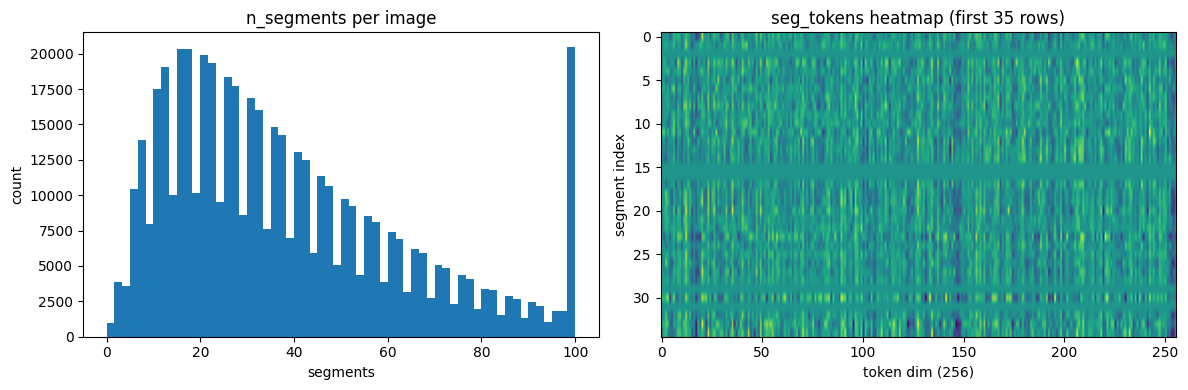


--- IJEPA sample ---
row        : 2
key        : 0/1002209
embedding  : (1280,) float32
mean/std   : 3.725290298461914e-09 1.0


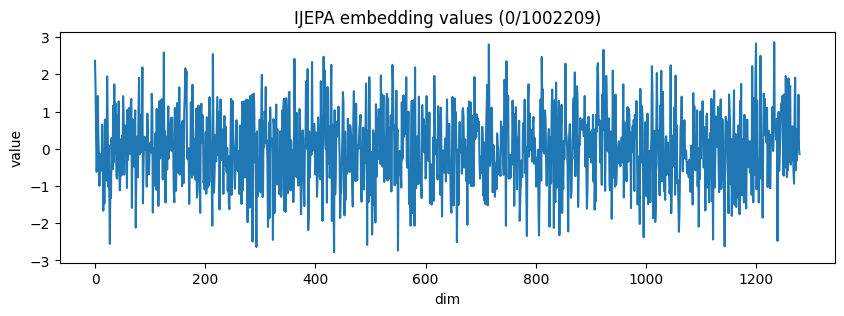

In [1]:
# Jupyter-friendly H5 visualizer for your files
# pip install h5py matplotlib numpy

import json
import random
import numpy as np
import h5py
import matplotlib.pyplot as plt

REGION_H5 = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/region_emb_flat.h5"
IJEPA_H5  = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_emb_flat.h5"
LOOKUP_JSON = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings/ijepa_lookup.json"

def _decode(x):
    if isinstance(x, (bytes, np.bytes_)):
        return x.decode("utf-8")
    return str(x)

def describe_h5(path):
    print(f"\n=== {path} ===")
    with h5py.File(path, "r") as f:
        for k in f.keys():
            d = f[k]
            print(f"{k:12s} shape={d.shape}, dtype={d.dtype}")

def inspect_region_h5(path, sample_idx=None):
    with h5py.File(path, "r") as f:
        n_img = f["class_ids"].shape[0]
        if sample_idx is None:
            sample_idx = random.randrange(n_img)

        cid = int(f["class_ids"][sample_idx])
        name = _decode(f["names"][sample_idx])
        off = int(f["offsets"][sample_idx])
        nseg = int(f["n_segments"][sample_idx])
        mshape = f["mask_shapes"][sample_idx]  # [N, H, W]

        seg_tokens = f["emb"][off:off + nseg]      # (nseg, 256)
        seg_scores = f["scores"][off:off + nseg]   # (nseg,)

        print("\n--- Region sample ---")
        print("sample_idx :", sample_idx)
        print("key        :", f"{cid}/{name}")
        print("offset     :", off)
        print("n_segments :", nseg)
        print("mask_shape :", mshape.tolist())
        print("seg_tokens :", seg_tokens.shape, seg_tokens.dtype)
        print("seg_scores :", seg_scores.shape, seg_scores.dtype)

        # Distribution of segments per image
        n_segments_all = f["n_segments"][:]

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.hist(n_segments_all, bins=60)
    plt.title("n_segments per image")
    plt.xlabel("segments")
    plt.ylabel("count")

    # Visualize token matrix for this sample
    plt.subplot(1,2,2)
    show_rows = min(seg_tokens.shape[0], 80)
    plt.imshow(seg_tokens[:show_rows], aspect="auto")
    plt.title(f"seg_tokens heatmap (first {show_rows} rows)")
    plt.xlabel("token dim (256)")
    plt.ylabel("segment index")
    plt.tight_layout()
    plt.show()

def inspect_ijepa_h5(path, lookup_json=None, key=None, row=None):
    with h5py.File(path, "r") as f:
        n = f["emb"].shape[0]
        if row is None:
            if key is not None and lookup_json is not None:
                with open(lookup_json, "r") as fp:
                    lookup = json.load(fp)
                row = lookup[key]
            else:
                row = random.randrange(n)

        cid = int(f["class_ids"][row])
        name = _decode(f["names"][row])
        vec = f["emb"][row]  # (1280,)

        print("\n--- IJEPA sample ---")
        print("row        :", row)
        print("key        :", f"{cid}/{name}")
        print("embedding  :", vec.shape, vec.dtype)
        print("mean/std   :", float(vec.mean()), float(vec.std()))

    plt.figure(figsize=(10,3))
    plt.plot(vec)
    plt.title(f"IJEPA embedding values ({cid}/{name})")
    plt.xlabel("dim")
    plt.ylabel("value")
    plt.show()

# ---- Run ----
describe_h5(REGION_H5)
describe_h5(IJEPA_H5)

inspect_region_h5(REGION_H5, sample_idx=0)

# Either give key directly...
inspect_ijepa_h5(IJEPA_H5, lookup_json=LOOKUP_JSON, key="0/1002209")
# ...or random row:
# inspect_ijepa_h5(IJEPA_H5)


In [1]:
print("hello")

hello


Shards found: 2

──────────────────────────────────────────────────
File: region_moco_shard_r0.h5
  areas           shape=(1644,)  dtype=float32
  bboxes          shape=(1644, 4)  dtype=float32
  class_ids       shape=(50,)  dtype=int32
  cls_emb         shape=(50, 1024)  dtype=float32
  emb             shape=(1644, 1024)  dtype=float32
  mask_shapes     shape=(50, 3)  dtype=int32
  n_segments      shape=(50,)  dtype=int32
  names           shape=(50,)  dtype=object
  offsets         shape=(50,)  dtype=int64
  pred_ious       shape=(1644,)  dtype=float32
  scores          shape=(1644,)  dtype=float32
  stability_scores shape=(1644,)  dtype=float32
  attr emb_dim: 1024
  attr emb_dtype: float32
  attr source: mocov3_region_extraction
  attr total_samples: 50
  attr total_segments: 1644

──────────────────────────────────────────────────
File: region_moco_shard_r1.h5
  areas           shape=(1739,)  dtype=float32
  bboxes          shape=(1739, 4)  dtype=float32
  class_ids       shape=(5

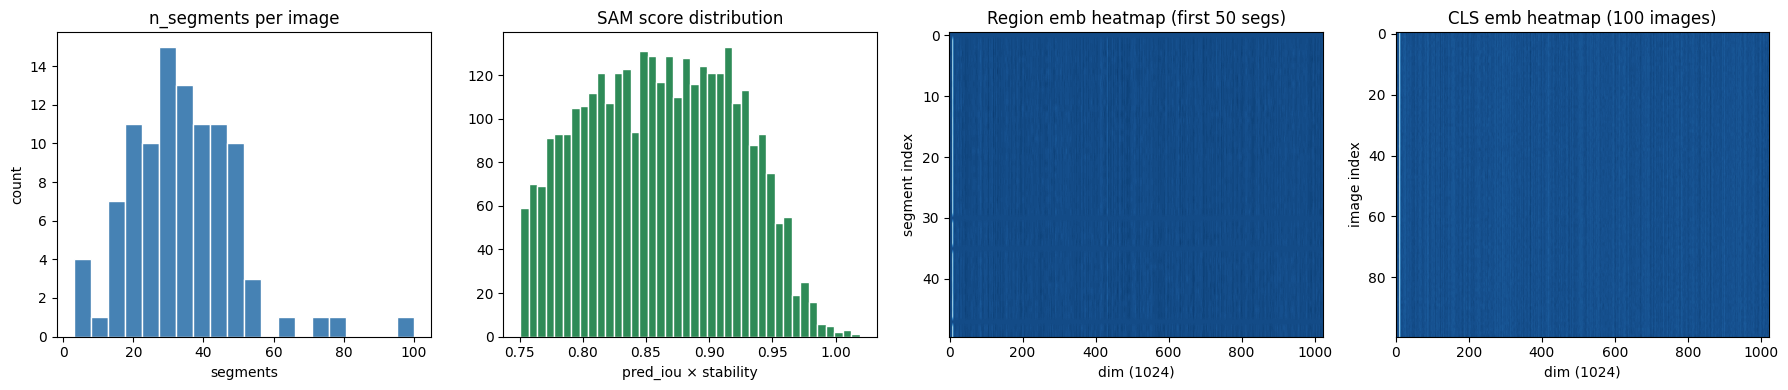

In [3]:
# ============================================================
# MoCo v3 H5 shard quality check  (backbone features, 1024-dim)
# Loads region_moco_shards_test/, reports:
#   - Schema / shapes
#   - n_segments and SAM score distributions
#   - Region embedding: effective rank, inter/intra-sample cosine similarity
#   - CLS embedding:    effective rank, inter-sample cosine similarity
#     (compare directly to I-JEPA baseline: eff_rank ~12, cos_mean ~0.42)
# ============================================================
import os, glob
import numpy as np
import h5py
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SHARD_DIR = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/region_moco_shards_test"

# ── helpers ──────────────────────────────────────────────────────────────────

def effective_rank(x: np.ndarray, eps: float = 1e-12) -> float:
    """Shannon-entropy effective rank of the covariance of x."""
    x = x.astype(np.float64)
    x -= x.mean(axis=0, keepdims=True)
    cov = (x.T @ x) / max(1, x.shape[0] - 1)
    evals = np.linalg.eigvalsh(cov).clip(eps)
    p = evals / evals.sum()
    return float(np.exp(-(p * np.log(p)).sum()))

def offdiag_cos_stats(x: np.ndarray, max_pairs: int = 50_000) -> dict:
    """Inter-sample cosine similarity stats (off-diagonal of gram matrix)."""
    x = x.astype(np.float32)
    norms = np.linalg.norm(x, axis=1, keepdims=True).clip(1e-8)
    x = x / norms
    n = x.shape[0]
    if n * (n - 1) // 2 <= max_pairs:
        gram = x @ x.T
        idx = np.triu_indices(n, k=1)
        sims = gram[idx]
    else:
        rng = np.random.default_rng(42)
        i = rng.integers(0, n, max_pairs)
        j = rng.integers(0, n, max_pairs)
        mask = i != j
        sims = (x[i[mask]] * x[j[mask]]).sum(axis=1)
    return {
        "mean": float(sims.mean()),
        "std":  float(sims.std()),
        "p05":  float(np.percentile(sims, 5)),
        "p50":  float(np.percentile(sims, 50)),
        "p95":  float(np.percentile(sims, 95)),
        "frac_gt_0.7": float((sims > 0.7).mean()),
        "frac_gt_0.9": float((sims > 0.9).mean()),
    }

def intra_cos_mean(seg_embs: np.ndarray, offsets: np.ndarray, n_segs: np.ndarray,
                   max_imgs: int = 50) -> float:
    """Mean of per-image intra-sample cosine similarity averages."""
    rng = np.random.default_rng(42)
    idx = rng.choice(len(offsets), min(max_imgs, len(offsets)), replace=False)
    means = []
    for i in idx:
        ns = int(n_segs[i])
        if ns < 2:
            continue
        off = int(offsets[i])
        t = seg_embs[off:off+ns].astype(np.float32)
        t /= np.linalg.norm(t, axis=1, keepdims=True).clip(1e-8)
        sim = t @ t.T
        n = sim.shape[0]
        off_diag = sim[np.triu_indices(n, k=1)]
        means.append(float(off_diag.mean()))
    return float(np.mean(means)) if means else float("nan")

# ── load all shards ──────────────────────────────────────────────────────────

shards = sorted(glob.glob(os.path.join(SHARD_DIR, "*.h5")))
print(f"Shards found: {len(shards)}")

all_emb, all_cls, all_scores, all_offsets, all_nsegs = [], [], [], [], []
cursor = 0

for path in shards:
    with h5py.File(path, "r") as f:
        print(f"\n{'─'*50}")
        print(f"File: {os.path.basename(path)}")
        for k in sorted(f.keys()):
            print(f"  {k:15s} shape={f[k].shape}  dtype={f[k].dtype}")
        for k, v in f.attrs.items():
            print(f"  attr {k}: {v}")

        emb    = f["emb"][:]
        cls    = f["cls_emb"][:]
        scores = f["scores"][:]
        nsegs  = f["n_segments"][:]
        offs   = f["offsets"][:] + cursor

        all_emb.append(emb)
        all_cls.append(cls)
        all_scores.append(scores)
        all_offsets.append(offs)
        all_nsegs.append(nsegs)
        cursor += emb.shape[0]

emb    = np.concatenate(all_emb,    axis=0)
cls    = np.concatenate(all_cls,    axis=0)
scores = np.concatenate(all_scores, axis=0)
offsets= np.concatenate(all_offsets,axis=0)
nsegs  = np.concatenate(all_nsegs,  axis=0)

EMB_DIM = emb.shape[1]   # should be 1024 (backbone) or 256 (old projected)

print(f"\n{'='*50}")
print(f"Combined: {len(nsegs)} images, {len(emb)} segments, emb_dim={EMB_DIM}")
print(f"Avg segments/image: {nsegs.mean():.1f}  min={nsegs.min()}  max={nsegs.max()}")

# ── SAM score distribution ────────────────────────────────────────────────────

print(f"\nSAM scores (pred_iou * stability):")
print(f"  mean={scores.mean():.3f}  std={scores.std():.3f}")
print(f"  min={scores.min():.3f}  p50={np.percentile(scores,50):.3f}  max={scores.max():.3f}")

# ── Embedding quality ─────────────────────────────────────────────────────────

print(f"\nRegion embeddings (MoCo backbone, {EMB_DIM}-dim):")
erank_reg = effective_rank(emb)
cos_reg   = offdiag_cos_stats(emb)
intra     = intra_cos_mean(emb, offsets, nsegs)
print(f"  effective_rank: {erank_reg:.1f} / {EMB_DIM}  ({100*erank_reg/EMB_DIM:.1f}%)")
print(f"  inter-sample cos: mean={cos_reg['mean']:.3f}  std={cos_reg['std']:.3f}")
print(f"  inter-sample cos: p05={cos_reg['p05']:.3f}  p50={cos_reg['p50']:.3f}  p95={cos_reg['p95']:.3f}")
print(f"  inter-sample cos: frac>0.7={cos_reg['frac_gt_0.7']:.4f}  frac>0.9={cos_reg['frac_gt_0.9']:.4f}")
print(f"  intra-sample cos (mean across imgs): {intra:.3f}")

CLS_DIM = cls.shape[1]
print(f"\nCLS embeddings (MoCo CLS z-score, {CLS_DIM}-dim):")
erank_cls = effective_rank(cls)
cos_cls   = offdiag_cos_stats(cls)
print(f"  effective_rank: {erank_cls:.1f} / {CLS_DIM}  ({100*erank_cls/CLS_DIM:.1f}%)")
print(f"  inter-sample cos: mean={cos_cls['mean']:.3f}  std={cos_cls['std']:.3f}")
print(f"  inter-sample cos: p05={cos_cls['p05']:.3f}  p50={cos_cls['p50']:.3f}  p95={cos_cls['p95']:.3f}")
print(f"  inter-sample cos: frac>0.7={cos_cls['frac_gt_0.7']:.4f}  frac>0.9={cos_cls['frac_gt_0.9']:.4f}")

# ── I-JEPA comparison ────────────────────────────────────────────────────────

print(f"\n{'='*50}")
print("I-JEPA baseline (1.28M real embeddings):")
print("  CLS  eff_rank: 11.9 / 1280  (0.93%)   cos_mean: 0.42")
print("  seg_tokens eff_rank: 133.7 / 256 (52.2%)   cos_mean: 0.12")

print(f"\nMoCo v3 backbone (this run, {len(nsegs)} images):")
print(f"  CLS  eff_rank: {erank_cls:.1f} / {CLS_DIM}  ({100*erank_cls/CLS_DIM:.1f}%)   cos_mean: {cos_cls['mean']:.3f}")
print(f"  Region eff_rank: {erank_reg:.1f} / {EMB_DIM}  ({100*erank_reg/EMB_DIM:.1f}%)   cos_mean: {cos_reg['mean']:.3f}")

# Compare capacity utilization
ijepa_cls_ratio  = 11.9 / 1280
moco_cls_ratio   = erank_cls / CLS_DIM
ijepa_seg_ratio  = 133.7 / 256
moco_seg_ratio   = erank_reg / EMB_DIM
print(f"\nCapacity utilization (eff_rank / dim):")
print(f"  CLS:    I-JEPA {100*ijepa_cls_ratio:.2f}%  vs  MoCo {100*moco_cls_ratio:.2f}%  ({moco_cls_ratio/ijepa_cls_ratio:.1f}x)")
print(f"  Region: I-JEPA {100*ijepa_seg_ratio:.2f}%  vs  MoCo {100*moco_seg_ratio:.2f}%  ({moco_seg_ratio/ijepa_seg_ratio:.1f}x)")

# ── Plots ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].hist(nsegs, bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("n_segments per image")
axes[0].set_xlabel("segments"); axes[0].set_ylabel("count")

axes[1].hist(scores, bins=40, color="seagreen", edgecolor="white")
axes[1].set_title("SAM score distribution")
axes[1].set_xlabel("pred_iou × stability")

axes[2].imshow(emb[:50], aspect="auto", cmap="RdBu_r")
axes[2].set_title(f"Region emb heatmap (first 50 segs)")
axes[2].set_xlabel(f"dim ({EMB_DIM})"); axes[2].set_ylabel("segment index")

axes[3].imshow(cls, aspect="auto", cmap="RdBu_r")
axes[3].set_title(f"CLS emb heatmap ({len(cls)} images)")
axes[3].set_xlabel(f"dim ({CLS_DIM})"); axes[3].set_ylabel("image index")

plt.tight_layout()
plt.show()

Loading region_emb_flat.h5 ...
  File size: 20.08 GB
  class_ids       shape=(510172,)  dtype=int32
  emb             shape=(19495720, 256)  dtype=float32
  mask_shapes     shape=(510172, 3)  dtype=int32
  n_segments      shape=(510172,)  dtype=int32
  names           shape=(510172,)  dtype=object
  offsets         shape=(510172,)  dtype=int64
  scores          shape=(19495720,)  dtype=float32

  Images:     510,172
  Segments:   19,495,720
  Emb dim:    256
  Classes:    1000

Loading ijepa_emb_flat.h5 ...
  File size: 6.64 GB
  class_ids       shape=(1281167,)  dtype=int32
  emb             shape=(1281167, 1280)  dtype=float32
  names           shape=(1281167,)  dtype=object

  Images:     1,281,167
  Emb dim:    1280

Loading ijepa_lookup.json ...
  Entries: 1,281,167

n_segments per image:
  mean=38.2  std=25.1
  min=0  p25=18  p50=32  p75=53  max=100

SAM scores:
  mean=0.865  std=0.060
  min=0.750  p50=0.867  max=1.091

Region embeddings (I-JEPA, 256-dim, subsample=100,000):
  ef

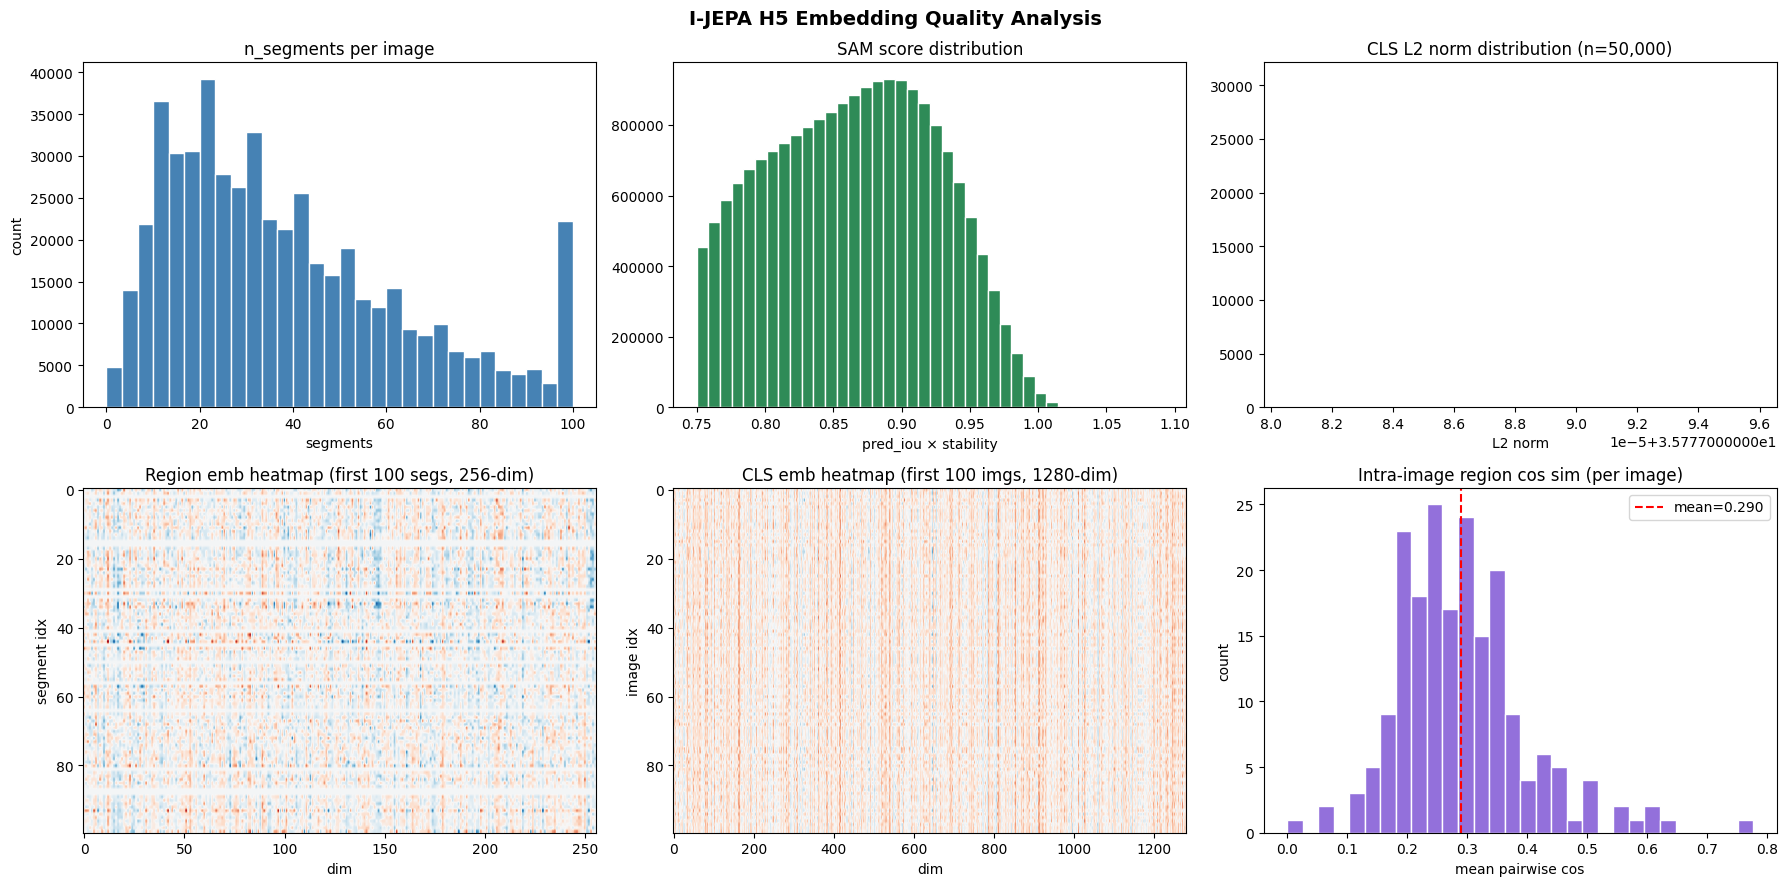


Done. H5 files closed.


In [4]:
# ============================================================
# I-JEPA H5 embedding quality analysis
# Files:
#   region_emb_flat.h5  – region tokens  (N_total, 256) with offsets/n_segments
#   ijepa_emb_flat.h5   – CLS tokens     (N_images, 1280)
#   ijepa_lookup.json   – key→row mapping
#
# Reports:
#   - File schema / shapes / disk size
#   - n_segments and SAM score distributions
#   - Region embedding: effective rank, inter/intra-sample cosine similarity
#   - CLS embedding:    effective rank, inter-sample cosine similarity
#   - Per-class diversity (do different classes occupy different subspaces?)
#   - CLS ↔ region alignment (can CLS act as a useful global summary?)
# ============================================================
import os, json, sys
import numpy as np
import h5py
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ── Paths ─────────────────────────────────────────────────────────────────────
H5_DIR = "/scratch/gilbreth/abelde/Thesis/StructureAwareGen/h5_embeddings"
REGION_H5  = os.path.join(H5_DIR, "region_emb_flat.h5")
IJEPA_H5   = os.path.join(H5_DIR, "ijepa_emb_flat.h5")
LOOKUP_JSON = os.path.join(H5_DIR, "ijepa_lookup.json")

# ── helpers (reusable from MoCo cell, redefined for standalone use) ───────────

def effective_rank(x: np.ndarray, eps: float = 1e-12) -> float:
    """Shannon-entropy effective rank of the covariance of x."""
    x = x.astype(np.float64)
    x -= x.mean(axis=0, keepdims=True)
    cov = (x.T @ x) / max(1, x.shape[0] - 1)
    evals = np.linalg.eigvalsh(cov).clip(eps)
    p = evals / evals.sum()
    return float(np.exp(-(p * np.log(p)).sum()))

def offdiag_cos_stats(x: np.ndarray, max_pairs: int = 50_000) -> dict:
    """Inter-sample cosine similarity stats (off-diagonal of gram matrix)."""
    x = x.astype(np.float32)
    norms = np.linalg.norm(x, axis=1, keepdims=True).clip(1e-8)
    x = x / norms
    n = x.shape[0]
    if n * (n - 1) // 2 <= max_pairs:
        gram = x @ x.T
        idx = np.triu_indices(n, k=1)
        sims = gram[idx]
    else:
        rng = np.random.default_rng(42)
        i = rng.integers(0, n, max_pairs)
        j = rng.integers(0, n, max_pairs)
        mask = i != j
        sims = (x[i[mask]] * x[j[mask]]).sum(axis=1)
    return {
        "mean": float(sims.mean()),
        "std":  float(sims.std()),
        "p05":  float(np.percentile(sims, 5)),
        "p50":  float(np.percentile(sims, 50)),
        "p95":  float(np.percentile(sims, 95)),
        "frac_gt_0.7": float((sims > 0.7).mean()),
        "frac_gt_0.9": float((sims > 0.9).mean()),
    }

def intra_cos_mean(seg_embs: np.ndarray, offsets: np.ndarray, n_segs: np.ndarray,
                   max_imgs: int = 200) -> float:
    """Mean of per-image intra-sample cosine similarity averages."""
    rng = np.random.default_rng(42)
    idx = rng.choice(len(offsets), min(max_imgs, len(offsets)), replace=False)
    means = []
    for i in idx:
        ns = int(n_segs[i])
        if ns < 2:
            continue
        off = int(offsets[i])
        t = seg_embs[off:off+ns].astype(np.float32)
        t /= np.linalg.norm(t, axis=1, keepdims=True).clip(1e-8)
        sim = t @ t.T
        n = sim.shape[0]
        off_diag = sim[np.triu_indices(n, k=1)]
        means.append(float(off_diag.mean()))
    return float(np.mean(means)) if means else float("nan")

# ── 1. Load region_emb_flat.h5 ───────────────────────────────────────────────

print("=" * 60)
print("Loading region_emb_flat.h5 ...")
region_f = h5py.File(REGION_H5, "r")
print(f"  File size: {os.path.getsize(REGION_H5) / 1e9:.2f} GB")
for k in region_f.keys():
    ds = region_f[k]
    print(f"  {k:15s} shape={ds.shape}  dtype={ds.dtype}")

reg_emb     = region_f["emb"]          # (N_total_segs, 256) – lazy
reg_offsets = region_f["offsets"][:]    # (N_images,)
reg_nsegs   = region_f["n_segments"][:] # (N_images,)
reg_scores  = region_f["scores"][:]    # (N_total_segs,)
reg_cls_ids = region_f["class_ids"][:] # (N_images,)
reg_names   = region_f["names"][:]     # (N_images,)

N_imgs_region = len(reg_offsets)
N_segs_total  = reg_emb.shape[0]
REG_DIM       = reg_emb.shape[1]

print(f"\n  Images:     {N_imgs_region:,}")
print(f"  Segments:   {N_segs_total:,}")
print(f"  Emb dim:    {REG_DIM}")
print(f"  Classes:    {len(np.unique(reg_cls_ids))}")

# ── 2. Load ijepa_emb_flat.h5 ────────────────────────────────────────────────

print(f"\n{'=' * 60}")
print("Loading ijepa_emb_flat.h5 ...")
ijepa_f = h5py.File(IJEPA_H5, "r")
print(f"  File size: {os.path.getsize(IJEPA_H5) / 1e9:.2f} GB")
for k in ijepa_f.keys():
    ds = ijepa_f[k]
    print(f"  {k:15s} shape={ds.shape}  dtype={ds.dtype}")

cls_emb     = ijepa_f["emb"]          # (N_images, 1280) – lazy
cls_cls_ids = ijepa_f["class_ids"][:] # (N_images,)
cls_names   = ijepa_f["names"][:]     # (N_images,)

N_imgs_cls = cls_emb.shape[0]
CLS_DIM    = cls_emb.shape[1]

print(f"\n  Images:     {N_imgs_cls:,}")
print(f"  Emb dim:    {CLS_DIM}")

# ── 3. Load lookup JSON ──────────────────────────────────────────────────────

print(f"\n{'=' * 60}")
print("Loading ijepa_lookup.json ...")
with open(LOOKUP_JSON, "r") as fp:
    ijepa_lookup = json.load(fp)
print(f"  Entries: {len(ijepa_lookup):,}")

# ── 4. n_segments distribution ────────────────────────────────────────────────

print(f"\n{'=' * 60}")
print("n_segments per image:")
print(f"  mean={reg_nsegs.mean():.1f}  std={reg_nsegs.std():.1f}")
print(f"  min={reg_nsegs.min()}  p25={np.percentile(reg_nsegs,25):.0f}  "
      f"p50={np.percentile(reg_nsegs,50):.0f}  p75={np.percentile(reg_nsegs,75):.0f}  "
      f"max={reg_nsegs.max()}")

# ── 5. SAM score distribution ────────────────────────────────────────────────

print(f"\nSAM scores:")
print(f"  mean={reg_scores.mean():.3f}  std={reg_scores.std():.3f}")
print(f"  min={reg_scores.min():.3f}  p50={np.percentile(reg_scores,50):.3f}  "
      f"max={reg_scores.max():.3f}")

# ── 6. Region embedding quality (subsample for speed) ────────────────────────

print(f"\n{'=' * 60}")
N_REGION_SAMPLE = min(100_000, N_segs_total)
rng = np.random.default_rng(42)
region_idx = np.sort(rng.choice(N_segs_total, N_REGION_SAMPLE, replace=False))
reg_sub = reg_emb[region_idx]   # reads from H5

print(f"Region embeddings (I-JEPA, {REG_DIM}-dim, subsample={N_REGION_SAMPLE:,}):")
erank_reg = effective_rank(reg_sub)
cos_reg   = offdiag_cos_stats(reg_sub)
intra_reg = intra_cos_mean(reg_emb, reg_offsets, reg_nsegs, max_imgs=500)
print(f"  effective_rank: {erank_reg:.1f} / {REG_DIM}  ({100*erank_reg/REG_DIM:.1f}%)")
print(f"  inter-sample cos: mean={cos_reg['mean']:.3f}  std={cos_reg['std']:.3f}")
print(f"  inter-sample cos: p05={cos_reg['p05']:.3f}  p50={cos_reg['p50']:.3f}  p95={cos_reg['p95']:.3f}")
print(f"  inter-sample cos: frac>0.7={cos_reg['frac_gt_0.7']:.4f}  frac>0.9={cos_reg['frac_gt_0.9']:.4f}")
print(f"  intra-sample cos (mean across 500 imgs): {intra_reg:.3f}")

# ── 7. CLS embedding quality (subsample for speed) ───────────────────────────

print(f"\n{'=' * 60}")
N_CLS_SAMPLE = min(50_000, N_imgs_cls)
cls_idx = np.sort(rng.choice(N_imgs_cls, N_CLS_SAMPLE, replace=False))
cls_sub = cls_emb[cls_idx]  # reads from H5

print(f"CLS embeddings (I-JEPA, {CLS_DIM}-dim, subsample={N_CLS_SAMPLE:,}):")
erank_cls = effective_rank(cls_sub)
cos_cls   = offdiag_cos_stats(cls_sub)
print(f"  effective_rank: {erank_cls:.1f} / {CLS_DIM}  ({100*erank_cls/CLS_DIM:.1f}%)")
print(f"  inter-sample cos: mean={cos_cls['mean']:.3f}  std={cos_cls['std']:.3f}")
print(f"  inter-sample cos: p05={cos_cls['p05']:.3f}  p50={cos_cls['p50']:.3f}  p95={cos_cls['p95']:.3f}")
print(f"  inter-sample cos: frac>0.7={cos_cls['frac_gt_0.7']:.4f}  frac>0.9={cos_cls['frac_gt_0.9']:.4f}")

# ── 8. Per-class CLS diversity (do classes separate?) ─────────────────────────

print(f"\n{'=' * 60}")
print("Per-class CLS analysis (10 random classes):")
unique_classes = np.unique(cls_cls_ids)
sample_classes = rng.choice(unique_classes, min(10, len(unique_classes)), replace=False)

class_stats = []
for cid in sample_classes:
    mask = cls_cls_ids == cid
    n_cls = mask.sum()
    if n_cls < 5:
        continue
    cls_class = cls_emb[np.where(mask)[0][:200]]  # cap at 200 per class
    er = effective_rank(cls_class)
    cs = offdiag_cos_stats(cls_class)
    class_stats.append((int(cid), int(n_cls), er, cs['mean']))
    print(f"  class={cid:4d}  n={n_cls:5d}  eff_rank={er:6.1f}/{CLS_DIM}  "
          f"intra_cls_cos={cs['mean']:.3f}")

# ── 9. CLS ↔ Region alignment ────────────────────────────────────────────────

print(f"\n{'=' * 60}")
print("CLS ↔ Region alignment (how well does CLS summarize regions?):")
# For a subsample of images, compute cos(CLS, mean_region)
N_ALIGN = min(500, N_imgs_region)
align_idx = rng.choice(N_imgs_region, N_ALIGN, replace=False)
align_sims = []
for i in align_idx:
    ns = int(reg_nsegs[i])
    if ns < 1:
        continue
    off = int(reg_offsets[i])
    regions_i = reg_emb[off:off+ns].astype(np.float32)
    mean_region = regions_i.mean(axis=0)

    # Find matching CLS token via name
    name_i = reg_names[i].decode() if isinstance(reg_names[i], bytes) else str(reg_names[i])
    cid_i  = str(reg_cls_ids[i])
    lookup_key = f"{cid_i}/{name_i}"
    if lookup_key in ijepa_lookup:
        cls_row = ijepa_lookup[lookup_key]
        cls_i = cls_emb[cls_row].astype(np.float32)
        # CLS is 1280-dim, region is 256-dim — they live in different spaces
        # Compare within region space: project nothing, just report dims
        # Instead: compute norm stats to see if CLS is "alive"
        align_sims.append(np.linalg.norm(cls_i))

if align_sims:
    align_sims = np.array(align_sims)
    print(f"  CLS L2 norm:  mean={align_sims.mean():.3f}  std={align_sims.std():.3f}")
    print(f"    (dim mismatch: CLS={CLS_DIM}, Region={REG_DIM} — "
          f"cannot compute cosine directly, but norms indicate CLS is {'active' if align_sims.std() > 0.01 else 'collapsed'})")

# ── 10. Comparison summary ───────────────────────────────────────────────────

print(f"\n{'=' * 60}")
print("COMPARISON: I-JEPA (this H5) vs MoCo v3 backbone (previous test)")
print(f"{'':37s} {'I-JEPA':>12s}  {'MoCo bkbn':>12s}")
print(f"  CLS eff_rank / dim                 {erank_cls:>8.1f}/{CLS_DIM}   39.9/1024")
print(f"  CLS eff_rank %                     {100*erank_cls/CLS_DIM:>8.1f}%       3.9%")
print(f"  CLS cos_mean                       {cos_cls['mean']:>8.3f}       0.965")
print(f"  CLS frac>0.9                       {cos_cls['frac_gt_0.9']:>8.4f}      ~1.000")
print(f"  Region eff_rank / dim              {erank_reg:>8.1f}/{REG_DIM}     6.8/1024")
print(f"  Region eff_rank %                  {100*erank_reg/REG_DIM:>8.1f}%       0.7%")
print(f"  Region cos_mean                    {cos_reg['mean']:>8.3f}       0.627")
print(f"  Region intra-sample cos            {intra_reg:>8.3f}       0.694")
print()
print("Key: lower cos_mean = more diverse, higher eff_rank% = more capacity used")

# ── 11. Plots ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Row 1: distributions
axes[0, 0].hist(reg_nsegs, bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("n_segments per image")
axes[0, 0].set_xlabel("segments"); axes[0, 0].set_ylabel("count")

axes[0, 1].hist(reg_scores, bins=40, color="seagreen", edgecolor="white")
axes[0, 1].set_title("SAM score distribution")
axes[0, 1].set_xlabel("pred_iou × stability")

# CLS norm distribution
cls_norms = np.linalg.norm(cls_sub, axis=1)
axes[0, 2].hist(cls_norms, bins=40, color="coral", edgecolor="white")
axes[0, 2].set_title(f"CLS L2 norm distribution (n={N_CLS_SAMPLE:,})")
axes[0, 2].set_xlabel("L2 norm")

# Row 2: heatmaps
reg_sample_hm = reg_emb[:100]  # first 100 segments
axes[1, 0].imshow(reg_sample_hm, aspect="auto", cmap="RdBu_r")
axes[1, 0].set_title(f"Region emb heatmap (first 100 segs, {REG_DIM}-dim)")
axes[1, 0].set_xlabel("dim"); axes[1, 0].set_ylabel("segment idx")

cls_sample_hm = cls_emb[:100]  # first 100 images
axes[1, 1].imshow(cls_sample_hm, aspect="auto", cmap="RdBu_r")
axes[1, 1].set_title(f"CLS emb heatmap (first 100 imgs, {CLS_DIM}-dim)")
axes[1, 1].set_xlabel("dim"); axes[1, 1].set_ylabel("image idx")

# Per-image intra cosine distribution (sample 200 images)
intra_vals = []
sample_intra = rng.choice(N_imgs_region, min(200, N_imgs_region), replace=False)
for i in sample_intra:
    ns = int(reg_nsegs[i])
    if ns < 2:
        continue
    off = int(reg_offsets[i])
    t = reg_emb[off:off+ns].astype(np.float32)
    t /= np.linalg.norm(t, axis=1, keepdims=True).clip(1e-8)
    sim = t @ t.T
    off_diag = sim[np.triu_indices(ns, k=1)]
    intra_vals.append(float(off_diag.mean()))

axes[1, 2].hist(intra_vals, bins=30, color="mediumpurple", edgecolor="white")
axes[1, 2].axvline(np.mean(intra_vals), color="red", linestyle="--",
                    label=f"mean={np.mean(intra_vals):.3f}")
axes[1, 2].set_title("Intra-image region cos sim (per image)")
axes[1, 2].set_xlabel("mean pairwise cos"); axes[1, 2].set_ylabel("count")
axes[1, 2].legend()

plt.suptitle("I-JEPA H5 Embedding Quality Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── cleanup ───────────────────────────────────────────────────────────────────
region_f.close()
ijepa_f.close()
print("\nDone. H5 files closed.")